# Import and summarize transcript-level estimates

## Library

In [3]:
BiocManager::install("tximport")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.20 (BiocManager 1.30.25), R 4.4.2 (2024-10-31)

Installing package(s) 'tximport'

Old packages: 'annotate', 'beachmat', 'BH', 'BiocSingular', 'Biostrings',
  'DelayedMatrixStats', 'effectsize', 'graph', 'GSEABase', 'GSVA', 'insight',
  'IRanges', 'lpSolve', 'matrixStats', 'preprocessCore', 'quantiseqr', 'rhdf5',
  'Rhdf5lib', 'ScaledMatrix', 'SingleCellExperiment', 'singscore',
  'sparseMatrixStats', 'XML', 'curl', 'openssl', 'pillar', 'processx', 'rpart',
  'xfun'



In [ ]:
library(tidyverse)
library(tximport)
library(ensembldb)
library(EnsDb.Hsapiens.v86)
library(edgeR)
library(matrixStats)
library(plotly)
library(biomaRt)
library(ggstatsplot)
library(dplyr)
library(limma)
library(tidyr)
library(lubridate)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
  

In [ ]:
samples <- read_csv("metaDataIR3.csv") %>%
  dplyr::filter(DIAGNOSIS %in% c("Control","Prodromal","PD"), CLINICAL_EVENT %in% c("BL","V02","V04","V06","V08"), QCflagIR3 == "pass")
dim(samples)

New names:
• `Specimen Bar Code` -> `Specimen Bar Code...3`
• `Specimen Bar Code` -> `Specimen Bar Code...8`
Rows: 4871 Columns: 72
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (9): HudAlphaID, QCflagIR3, Specimen Bar Code...3, GENDER, DIAGNOSIS, C...
dbl (63): PATNO, Quantity (ug), Concentration (ng/ul), Concentration Flag, S...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 2839   72

In [ ]:
base_dir <- "quant"
  samples <- samples %>% mutate(
    path_phase1 = file.path(
      base_dir,
      paste0("PPMI-Phase1-IR3.", PATNO, ".",
             CLINICAL_EVENT, ".", `Specimen Bar Code...3`, ".",
             HudAlphaID, ".longRNA-NEBKAP.salmon.transcripts.sf")
    ),
    path_phase2 = file.path(
      base_dir,
      paste0("PPMI-Phase2-IR3.", PATNO, ".",
             CLINICAL_EVENT, ".", `Specimen Bar Code...3`, ".",
             HudAlphaID, ".longRNA-NEBKAP.salmon.transcripts.sf")
    )
  )

In [ ]:
dim(samples)

[1] 2839   74

In [ ]:
  samples <- samples %>% mutate(
    exists_phase1 = file.exists(path_phase1),
    exists_phase2 = file.exists(path_phase2)
  )

In [ ]:
  samples <- samples %>% mutate(
    final_path = ifelse(exists_phase1, path_phase1, ifelse(exists_phase2, path_phase2, NA))
  ) %>% filter(!is.na(final_path))

In [ ]:
head(samples)

HudAlphaID,QCflagIR3,Specimen Bar Code...3,PATNO,GENDER,DIAGNOSIS,CLINICAL_EVENT,Specimen Bar Code...8,Quantity (ug),Concentration (ng/ul),⋯,PCT_MRNA_BASES,MEDIAN_5PRIME_TO_3PRIME_BIAS,PCT_R1_TRANSCRIPT_STRAND_READS,MEDIAN_5PRIME_BIAS,PCT_USABLE_BASES,path_phase1,path_phase2,exists_phase1,exists_phase2,final_path
<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<lgl>,<lgl>,<chr>
5104-SL-0001,pass,0000373111,3174,Male,PD,V08,0000373111,1.0,115.90,⋯,50.4726,1.191875,1.8975,1.019442,47.9359,quant/PPMI-Phase1-IR3.3174.V08.0000373111.5104-SL-0001.longRNA-NEBKAP.salmon.transcripts.sf,quant/PPMI-Phase2-IR3.3174.V08.0000373111.5104-SL-0001.longRNA-NEBKAP.salmon.transcripts.sf,FALSE,TRUE,quant/PPMI-Phase2-IR3.3174.V08.0000373111.5104-SL-0001.longRNA-NEBKAP.salmon.transcripts.sf
5104-SL-0002,pass,PP0016-0526,3201,Female,Control,BL,PP0016-0526,1.0,80.07,⋯,40.6987,1.058616,1.8572,0.965040,39.6130,quant/PPMI-Phase1-IR3.3201.BL.PP0016-0526.5104-SL-0002.longRNA-NEBKAP.salmon.transcripts.sf,quant/PPMI-Phase2-IR3.3201.BL.PP0016-0526.5104-SL-0002.longRNA-NEBKAP.salmon.transcripts.sf,TRUE,FALSE,quant/PPMI-Phase1-IR3.3201.BL.PP0016-0526.5104-SL-0002.longRNA-NEBKAP.salmon.transcripts.sf
5104-SL-0003,pass,0003125874,3057,Female,Control,V06,0003125874,1.0,219.70,⋯,36.0884,1.095971,4.5679,0.997003,34.8096,quant/PPMI-Phase1-IR3.3057.V06.0003125874.5104-SL-0003.longRNA-NEBKAP.salmon.transcripts.sf,quant/PPMI-Phase2-IR3.3057.V06.0003125874.5104-SL-0003.longRNA-NEBKAP.salmon.transcripts.sf,TRUE,FALSE,quant/PPMI-Phase1-IR3.3057.V06.0003125874.5104-SL-0003.longRNA-NEBKAP.salmon.transcripts.sf
5104-SL-0004,pass,0003179818,4126,Male,PD,V04,0003179818,1.0,100.06,⋯,48.3407,1.170152,1.6215,1.013765,45.3119,quant/PPMI-Phase1-IR3.4126.V04.0003179818.5104-SL-0004.longRNA-NEBKAP.salmon.transcripts.sf,quant/PPMI-Phase2-IR3.4126.V04.0003179818.5104-SL-0004.longRNA-NEBKAP.salmon.transcripts.sf,FALSE,TRUE,quant/PPMI-Phase2-IR3.4126.V04.0003179818.5104-SL-0004.longRNA-NEBKAP.salmon.transcripts.sf
5104-SL-0005,pass,0003164601,4117,Female,PD,BL,0003164601,1.0,124.40,⋯,35.8255,1.113733,1.9322,0.985280,34.8793,quant/PPMI-Phase1-IR3.4117.BL.0003164601.5104-SL-0005.longRNA-NEBKAP.salmon.transcripts.sf,quant/PPMI-Phase2-IR3.4117.BL.0003164601.5104-SL-0005.longRNA-NEBKAP.salmon.transcripts.sf,TRUE,FALSE,quant/PPMI-Phase1-IR3.4117.BL.0003164601.5104-SL-0005.longRNA-NEBKAP.salmon.transcripts.sf
5104-SL-0006,pass,0003119973,3057,Female,Control,V04,0003119973,1.1,131.12,⋯,41.0826,1.073169,2.6058,0.920747,37.9144,quant/PPMI-Phase1-IR3.3057.V04.0003119973.5104-SL-0006.longRNA-NEBKAP.salmon.transcripts.sf,quant/PPMI-Phase2-IR3.3057.V04.0003119973.5104-SL-0006.longRNA-NEBKAP.salmon.transcripts.sf,FALSE,TRUE,quant/PPMI-Phase2-IR3.3057.V04.0003119973.5104-SL-0006.longRNA-NEBKAP.salmon.transcripts.sf


In [ ]:
View(dplyr::select(samples,PATNO,exists_phase1,exists_phase2,final_path))

PATNO,exists_phase1,exists_phase2,final_path
<dbl>,<lgl>,<lgl>,<chr>
3174,FALSE,TRUE,quant/PPMI-Phase2-IR3.3174.V08.0000373111.5104-SL-0001.longRNA-NEBKAP.salmon.transcripts.sf
3201,TRUE,FALSE,quant/PPMI-Phase1-IR3.3201.BL.PP0016-0526.5104-SL-0002.longRNA-NEBKAP.salmon.transcripts.sf
3057,TRUE,FALSE,quant/PPMI-Phase1-IR3.3057.V06.0003125874.5104-SL-0003.longRNA-NEBKAP.salmon.transcripts.sf
4126,FALSE,TRUE,quant/PPMI-Phase2-IR3.4126.V04.0003179818.5104-SL-0004.longRNA-NEBKAP.salmon.transcripts.sf
4117,TRUE,FALSE,quant/PPMI-Phase1-IR3.4117.BL.0003164601.5104-SL-0005.longRNA-NEBKAP.salmon.transcripts.sf
3057,FALSE,TRUE,quant/PPMI-Phase2-IR3.3057.V04.0003119973.5104-SL-0006.longRNA-NEBKAP.salmon.transcripts.sf
3471,FALSE,TRUE,quant/PPMI-Phase2-IR3.3471.BL.PP0015-6713.5104-SL-0007.longRNA-NEBKAP.salmon.transcripts.sf
3174,TRUE,FALSE,quant/PPMI-Phase1-IR3.3174.V04.0003162443.5104-SL-0008.longRNA-NEBKAP.salmon.transcripts.sf
3661,TRUE,FALSE,quant/PPMI-Phase1-IR3.3661.V04.0003169393.5104-SL-0009.longRNA-NEBKAP.salmon.transcripts.sf


In [ ]:
dim(samples)

[1] 2839   77

In [7]:
samples$sample_id <- paste(samples$PATNO, samples$CLINICAL_EVENT, sep = "_")

In [ ]:
View(dplyr::select(samples,PATNO,exists_phase1,exists_phase2,final_path,sample_id, PATNO, CLINICAL_EVENT))

PATNO,exists_phase1,exists_phase2,final_path,sample_id,CLINICAL_EVENT
<dbl>,<lgl>,<lgl>,<chr>,<chr>,<chr>
3174,FALSE,TRUE,quant/PPMI-Phase2-IR3.3174.V08.0000373111.5104-SL-0001.longRNA-NEBKAP.salmon.transcripts.sf,3174_V08,V08
3201,TRUE,FALSE,quant/PPMI-Phase1-IR3.3201.BL.PP0016-0526.5104-SL-0002.longRNA-NEBKAP.salmon.transcripts.sf,3201_BL,BL
3057,TRUE,FALSE,quant/PPMI-Phase1-IR3.3057.V06.0003125874.5104-SL-0003.longRNA-NEBKAP.salmon.transcripts.sf,3057_V06,V06
4126,FALSE,TRUE,quant/PPMI-Phase2-IR3.4126.V04.0003179818.5104-SL-0004.longRNA-NEBKAP.salmon.transcripts.sf,4126_V04,V04
4117,TRUE,FALSE,quant/PPMI-Phase1-IR3.4117.BL.0003164601.5104-SL-0005.longRNA-NEBKAP.salmon.transcripts.sf,4117_BL,BL
3057,FALSE,TRUE,quant/PPMI-Phase2-IR3.3057.V04.0003119973.5104-SL-0006.longRNA-NEBKAP.salmon.transcripts.sf,3057_V04,V04
3471,FALSE,TRUE,quant/PPMI-Phase2-IR3.3471.BL.PP0015-6713.5104-SL-0007.longRNA-NEBKAP.salmon.transcripts.sf,3471_BL,BL
3174,TRUE,FALSE,quant/PPMI-Phase1-IR3.3174.V04.0003162443.5104-SL-0008.longRNA-NEBKAP.salmon.transcripts.sf,3174_V04,V04
3661,TRUE,FALSE,quant/PPMI-Phase1-IR3.3661.V04.0003169393.5104-SL-0009.longRNA-NEBKAP.salmon.transcripts.sf,3661_V04,V04


In [ ]:
length(unique(samples$sample_id))

[1] 2839

In [ ]:
samples <- read_csv("metaDataIR3_paths_transcripts.csv")

Rows: 2839 Columns: 74
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (11): HudAlphaID, QCflagIR3, Specimen Bar Code, GENDER, DIAGNOSIS, CLINI...
dbl (63): PATNO, Quantity (ug), Concentration (ng/ul), Concentration Flag, S...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
existence_path <- samples$final_path
names(existence_path) <- samples$sample_id

In [ ]:
Tx <- transcripts(EnsDb.Hsapiens.v86, columns = c("tx_id", "gene_name"))
Tx <- as_tibble(Tx)
Tx <- dplyr::rename(Tx, target_id = tx_id)
Tx <- dplyr::select(Tx, "target_id", "gene_name") 

In [ ]:
Txi_script <- tximport(
  existence_path,
  type = "salmon",
  tx2gene = Tx, 
  txOut = TRUE, 
  countsFromAbundance = "scaledTPM",
  ignoreTxVersion = TRUE 
)

reading in files with read_tsv

1 
2 
3 
4 
5 
6 
7 
8 
9 
10 
11 
12 
13 
14 
15 
16 
17 
18 
19 
20 
21 
22 
23 
24 
25 
26 
27 
28 
29 
30 
31 
32 
33 
34 
35 
36 
37 
38 
39 
40 
41 
42 
43 
44 
45 
46 
47 
48 
49 
50 
51 
52 
53 
54 
55 
56 
57 
58 
59 
60 
61 
62 
63 
64 
65 
66 
67 
68 
69 
70 
71 
72 
73 
74 
75 
76 
77 
78 
79 
80 
81 
82 
83 
84 
85 
86 
87 
88 
89 
90 
91 
92 
93 
94 
95 
96 
97 
98 
99 
100 
101 
102 
103 
104 
105 
106 
107 
108 
109 
110 
111 
112 
113 
114 
115 
116 
117 
118 
119 
120 
121 
122 
123 
124 
125 
126 
127 
128 
129 
130 
131 
132 
133 
134 
135 
136 
137 
138 
139 
140 
141 
142 
143 
144 
145 
146 
147 
148 
149 
150 
151 
152 
153 
154 
155 
156 
157 
158 
159 
160 
161 
162 
163 
164 
165 
166 
167 
168 
169 
170 
171 
172 
173 
174 
175 
176 
177 
178 
179 
180 
181 
182 
183 
184 
185 
186 
187 
188 
189 
190 
191 
192 
193 
194 
195 
196 
197 
198 
199 
200 
201 
202 
203 
204 
205 
206 
207 
208 
209 
210 
211 
212 
213 
214 
215 
2

In [ ]:
all.equal(colnames(Txi_script$counts), names(existence_path)) # Should return TRUE

[1] TRUE

In [ ]:
str(Txi_script)

List of 4
 $ abundance          : num [1:205870, 1:2839] 0.375 0 0.462 0 0 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:205870] "ENST00000456328.2" "ENST00000450305.2" "ENST00000488147.1" "ENST00000619216.1" ...
  .. ..$ : chr [1:2839] "3174_V08" "3201_BL" "3057_V06" "4126_V04" ...
 $ counts             : num [1:205870, 1:2839] 36.4 0 44.9 0 0 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:205870] "ENST00000456328.2" "ENST00000450305.2" "ENST00000488147.1" "ENST00000619216.1" ...
  .. ..$ : chr [1:2839] "3174_V08" "3201_BL" "3057_V06" "4126_V04" ...
 $ length             : num [1:205870, 1:2839] 1557 289 1377 17 352 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:205870] "ENST00000456328.2" "ENST00000450305.2" "ENST00000488147.1" "ENST00000619216.1" ...
  .. ..$ : chr [1:2839] "3174_V08" "3201_BL" "3057_V06" "4126_V04" ...
 $ countsFromAbundance: chr "scaledTPM"


In [ ]:
saveRDS(Txi_script, "Txi_script.rds")

In [10]:
myTPM <- Txi_script$abundance
myCounts <- Txi_script$counts
dge <- DGEList(myCounts)
head(dge)

An object of class "DGEList"
$counts
                  3174_V08  3201_BL 3057_V06 4126_V04   4117_BL  3057_V04
ENST00000456328.2 36.41176 19.90294 30.36700 15.65897  7.334756 53.287286
ENST00000450305.2  0.00000  0.00000  0.00000  0.00000  0.000000  0.000000
ENST00000488147.1 44.86677 30.11305 11.76108 27.52917 22.425752 22.055085
ENST00000619216.1  0.00000  0.00000  0.00000  0.00000  0.000000 28.107919
ENST00000473358.1  0.00000  0.00000  0.00000  0.00000  0.000000  0.000000
ENST00000469289.1  0.00000  0.00000  0.00000  0.00000  6.116235  1.601296
                    3471_BL 3174_V04 3661_V04  3551_V06  3435_BL  3201_V04
ENST00000456328.2  6.686652 30.09517 14.39140  9.383784 27.63383  9.638485
ENST00000450305.2  0.000000  0.00000  0.00000  0.000000  0.00000  0.000000
ENST00000488147.1 23.454763 35.54421 40.57481 18.201556 19.02684 36.407114
ENST00000619216.1  0.000000  0.00000  0.00000  0.000000 20.85636  0.000000
ENST00000473358.1  0.000000  0.00000  0.00000  0.000000 10.55101  0.000000
ENST00000469289.1  1.633104  0.00000  0.00000  0.000000  0.00000  0.000000
                   3173_BL 3013_V04 4117_V08 3173_V08  3212_V06 4055_V08
ENST00000456328.2 28.57897 56.41407 20.13618 38.22303 52.889137 22.42509
ENST00000450305.2  0.00000  0.00000  0.00000  0.00000  0.000000  0.00000
ENST00000488147.1 48.29540 34.01943 48.13817 29.25700 19.732617 35.91007
ENST00000619216.1  0.00000  0.00000  0.00000  0.00000  0.000000  0.00000
ENST00000473358.1  0.00000  0.00000  0.00000 16.17762 30.578073  0.00000
ENST00000469289.1  0.00000  0.00000  0.00000  0.00000  4.418372  0.00000
                  3201_V06 4117_V04  3479_BL  3013_V08 4126_V08 4117_V06
ENST00000456328.2 41.64774 21.99641 39.08541 53.251472 15.89791 17.36187
ENST00000450305.2  0.00000  0.00000  0.00000  0.000000  0.00000  0.00000
ENST00000488147.1 29.26184 30.72823 33.52348 34.862832 34.02904 15.75196
ENST00000619216.1  0.00000  0.00000  0.00000  0.000000  0.00000  0.00000
ENST00000473358.1  0.00000  0.00000  0.00000  2.214538  0.00000  0.00000
ENST00000469289.1 11.61141  0.00000  0.00000  0.000000  0.00000  0.00000
                   3011_V06  4110_BL  3174_BL 3435_V08  3435_V04 3385_V06
ENST00000456328.2  49.21623 25.45049 17.57392 13.35735  9.155901 9.195395
ENST00000450305.2   0.00000  0.00000  0.00000  0.00000  0.000000 0.000000
ENST00000488147.1  14.03257 36.75291 36.91889 25.01499 17.578891 6.336440
ENST00000619216.1 115.10849  0.00000  0.00000  0.00000  0.000000 0.000000
ENST00000473358.1  29.54261  0.00000  0.00000  0.00000  0.000000 0.000000
ENST00000469289.1   0.00000  0.00000  0.00000  0.00000  0.000000 0.000000
                  3385_V08 3479_V08  3454_BL 3454_V06 4110_V04  3415_V04
ENST00000456328.2 19.91300 31.04007 18.76031 28.09638 27.91667 33.042895
ENST00000450305.2  0.00000  0.00000  0.00000  0.00000  0.00000  0.000000
ENST00000488147.1 22.90537 33.52706 33.14164 22.30345 43.30292 15.279697
ENST00000619216.1  0.00000  0.00000  0.00000  0.00000  0.00000  0.000000
ENST00000473358.1  0.00000  0.00000  0.00000  0.00000  0.00000  3.502309
ENST00000469289.1  0.00000  0.00000  0.00000  0.00000  0.00000  0.000000
                   3471_V04  3479_V06  3415_BL  3376_BL 3415_V08 3087_V08
ENST00000456328.2 45.359827 107.65886 19.36187 49.14675 14.91520 17.37808
ENST00000450305.2  0.000000   0.00000  0.00000  0.00000  0.00000  0.00000
ENST00000488147.1  4.715532  70.86008 15.95245 31.11905 21.87989 42.84464
ENST00000619216.1  0.000000   0.00000  0.00000  0.00000  0.00000  0.00000
ENST00000473358.1 19.802109   0.00000  4.95859  0.00000  0.00000  0.00000
ENST00000469289.1  0.000000   0.00000  0.00000  0.00000  0.00000  0.00000
                   3023_BL   3661_BL  3087_BL  3551_BL 3174_V06 3023_V04
ENST00000456328.2 17.53466  7.554703 35.60518 27.79318 71.34378 22.76963
ENST00000450305.2  0.00000  0.000000  0.00000  0.00000  0.00000  0.00000
ENST00000488147.1 23.51311 41.697118 30.83788 28.30239 31.39020 23.74396
ENST00000619216.1  0.00000  0.000000  0.00000  0.00000  0.0

In [11]:
log2.cpm <- cpm(dge, log = TRUE)
log2.cpm.df <- as_tibble(log2.cpm, rownames = "geneID")

# Filter and normalization


In [ ]:
load("PAR.UPDRS.df.RData")

File downloaded:

• PAR.UPDRS.df.RData <id: 1f8Owh2bw19zcpz0Im_GlKAvhVb9yE4Vi>

Saved locally as:

• PAR.UPDRS.df.RData



In [ ]:
head(PAR.UPDRS)

,PATNO,BIRTHDT,COHORT_DEFINITION,GENETIC_SUBGROUP,ENROLL_AGE,ENROLL_DATE,ENROLL_STATUS,SEX,HANDED,PD_Diagnosis_Date,INFODT,EVENT_ID,Part1,Part1P,Part2,Part3,HY_Stage,TOTAL_UPDRS,samples_ID
,<dbl>,<date>,<chr>,<fct>,<dbl>,<date>,<chr>,<chr>,<chr>,<date>,<date>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,3000,1941-12-01,Healthy Control,,69.1,2011-02-01,Enrolled,Female,Right,NA,2019-03-01,V15,0,2,0,5,0,5,3000_V15
2,3000,1941-12-01,Healthy Control,,69.1,2011-02-01,Enrolled,Female,Right,NA,2014-03-01,V08,3,6,0,2,0,5,3000_V08
3,3000,1941-12-01,Healthy Control,,69.1,2011-02-01,Enrolled,Female,Right,NA,2021-05-01,V17,1,4,0,3,0,4,3000_V17
4,3000,1941-12-01,Healthy Control,,69.1,2011-02-01,Enrolled,Female,Right,NA,2011-02-01,BL,3,3,0,4,0,7,3000_BL
5,3000,1941-12-01,Healthy Control,,69.1,2011-02-01,Enrolled,Female,Right,NA,2015-03-01,V10,0,6,0,19,0,19,3000_V10
6,3000,1941-12-01,Healthy Control,,69.1,2011-02-01,Enrolled,Female,Right,NA,2016-04-01,V12,3,8,0,3,0,6,3000_V12


In [ ]:
dim(PAR.UPDRS)

[1] 20048    19

In [13]:
PAR.UPDRS2 = PAR.UPDRS %>% dplyr::filter (samples_ID %in% samples$sample_id)

In [ ]:
head(PAR.UPDRS2)

,PATNO,BIRTHDT,COHORT_DEFINITION,GENETIC_SUBGROUP,ENROLL_AGE,ENROLL_DATE,ENROLL_STATUS,SEX,HANDED,PD_Diagnosis_Date,INFODT,EVENT_ID,Part1,Part1P,Part2,Part3,HY_Stage,TOTAL_UPDRS,samples_ID
,<dbl>,<date>,<chr>,<fct>,<dbl>,<date>,<chr>,<chr>,<chr>,<date>,<date>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,3000,1941-12-01,Healthy Control,,69.1,2011-02-01,Enrolled,Female,Right,NA,2014-03-01,V08,3,6,0,2,0,5,3000_V08
2,3000,1941-12-01,Healthy Control,,69.1,2011-02-01,Enrolled,Female,Right,NA,2011-02-01,BL,3,3,0,4,0,7,3000_BL
3,3000,1941-12-01,Healthy Control,,69.1,2011-02-01,Enrolled,Female,Right,NA,2013-02-01,V06,3,3,0,4,0,7,3000_V06
4,3000,1941-12-01,Healthy Control,,69.1,2011-02-01,Enrolled,Female,Right,NA,2012-03-01,V04,1,4,0,1,0,2,3000_V04
5,3001,1946-01-01,Parkinson's Disease,SRDC,65.1,2011-03-01,Enrolled,Male,Left,2010-04-01,2014-04-01,V08,1,10,6,34,2,41,3001_V08
6,3001,1946-01-01,Parkinson's Disease,SRDC,65.1,2011-03-01,Enrolled,Male,Left,2010-04-01,2011-08-01,V02,0,7,3,23,2,26,3001_V02


In [ ]:
PAR.UPDRS2$INFO_age <- as.numeric(difftime(PAR.UPDRS2$INFODT, PAR.UPDRS2$BIRTHDT, units = "days")) %/% 365
# Print the DataFrame to check
head(PAR.UPDRS2)

,PATNO,BIRTHDT,COHORT_DEFINITION,GENETIC_SUBGROUP,ENROLL_AGE,ENROLL_DATE,ENROLL_STATUS,SEX,HANDED,PD_Diagnosis_Date,INFODT,EVENT_ID,Part1,Part1P,Part2,Part3,HY_Stage,TOTAL_UPDRS,samples_ID,INFO_age
,<dbl>,<date>,<chr>,<fct>,<dbl>,<date>,<chr>,<chr>,<chr>,<date>,<date>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,3000,1941-12-01,Healthy Control,,69.1,2011-02-01,Enrolled,Female,Right,NA,2014-03-01,V08,3,6,0,2,0,5,3000_V08,72
2,3000,1941-12-01,Healthy Control,,69.1,2011-02-01,Enrolled,Female,Right,NA,2011-02-01,BL,3,3,0,4,0,7,3000_BL,69
3,3000,1941-12-01,Healthy Control,,69.1,2011-02-01,Enrolled,Female,Right,NA,2013-02-01,V06,3,3,0,4,0,7,3000_V06,71
4,3000,1941-12-01,Healthy Control,,69.1,2011-02-01,Enrolled,Female,Right,NA,2012-03-01,V04,1,4,0,1,0,2,3000_V04,70
5,3001,1946-01-01,Parkinson's Disease,SRDC,65.1,2011-03-01,Enrolled,Male,Left,2010-04-01,2014-04-01,V08,1,10,6,34,2,41,3001_V08,68
6,3001,1946-01-01,Parkinson's Disease,SRDC,65.1,2011-03-01,Enrolled,Male,Left,2010-04-01,2011-08-01,V02,0,7,3,23,2,26,3001_V02,65


In [17]:
agedf <- dplyr::select( PAR.UPDRS2, PATNO, ENROLL_AGE, samples_ID, INFO_age, EVENT_ID)
head(agedf)

,PATNO,ENROLL_AGE,samples_ID,INFO_age,EVENT_ID
,<dbl>,<dbl>,<chr>,<dbl>,<chr>
1,3000,69.1,3000_V08,72,V08
2,3000,69.1,3000_BL,69,BL
3,3000,69.1,3000_V06,71,V06
4,3000,69.1,3000_V04,70,V04
5,3001,65.1,3001_V08,68,V08
6,3001,65.1,3001_V02,65,V02


In [19]:
agedf <- agedf %>% rename ("sample_id" = "samples_ID")

In [22]:
samples <- samples %>%
  left_join(agedf, by = "sample_id")

In [27]:
groups2 <- factor(samples$DIAGNOSIS)
keepTheseGenes4 <-filterByExpr(dge, group = groups2)

In [28]:
install.packages("reshape2")

Installing package into '/content/library'
(as 'lib' is unspecified)



In [29]:
library("dplyr")
library ("reshape2")
library ("ggplot2")
library ("edgeR")



Attaching package: 'reshape2'


The following object is masked from 'package:tidyr':

    smiths




In [30]:
beforeFiltering_plot <- dge %>%
  cpm(log = TRUE) %>%
  melt %>%
  dplyr::filter(is.finite(value)) %>%
   mutate(Var2 = as.factor(Var2)) %>%
  ggplot(aes(x = value, colour = Var2,group = Var2)) +
  geom_density() +
  guides(colour = FALSE) +
  ggtitle("A. Before filtering", subtitle = paste0(nrow(dge), " genes")) +
  labs(x = "logCPM", y = "Density")

Warning message:
"The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as
of ggplot2 3.3.4."


In [35]:
afterFiltering_plot4 <- dge %>%
  cpm(log = TRUE) %>%
  magrittr::extract(keepTheseGenes4,) %>%
  melt %>%
  dplyr::filter(is.finite(value)) %>%
   mutate(Var2 = as.factor(Var2)) %>%
  ggplot(aes(x = value, colour = Var2)) +
  geom_density() +
  guides(colour = FALSE) +
  ggtitle("B. After filtering filterByExpr", subtitle = paste0(table(keepTheseGenes4)[[2]], " genes"))+
  labs(x = "logCPM", y = "Density")

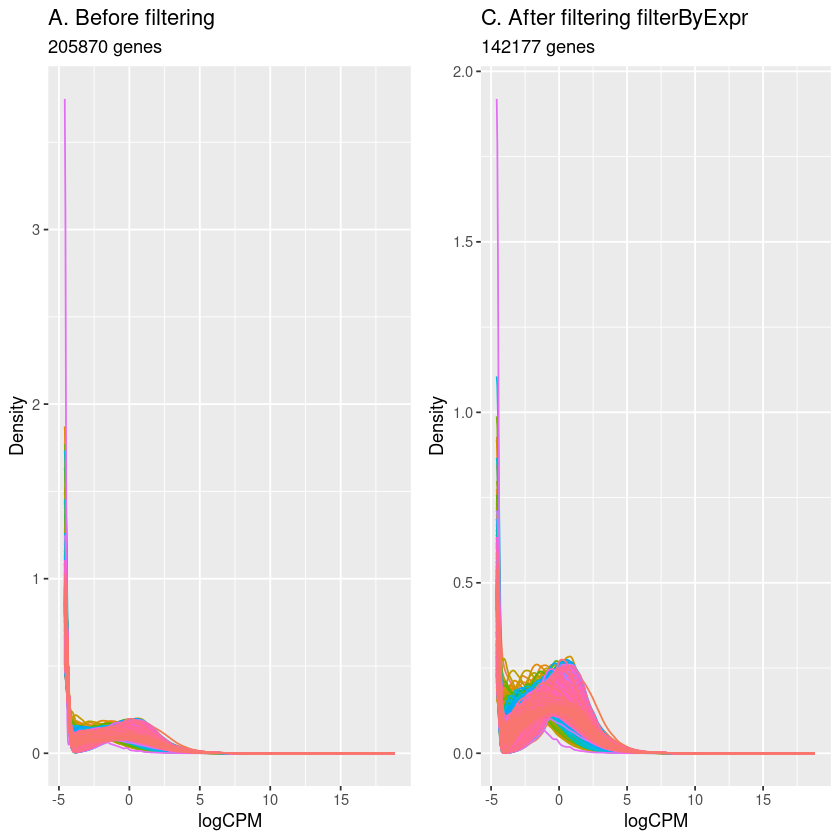

In [32]:
cowplot::plot_grid(beforeFiltering_plot,afterFiltering_plot4)

In [37]:
dge.filtered <- dge[keepTheseGenes4,]
dim(dge.filtered)

[1] 142177   2839

In [ ]:
dge.filtered.norm <- calcNormFactors(dge.filtered, method = "TMM")
log2.cpm.filtered.norm <- cpm(dge.filtered.norm, log = TRUE)
log2.cpm.filtered.norm.df <- as_tibble(log2.cpm.filtered.norm, rownames = "geneID")

In [39]:
head(log2.cpm.filtered.norm.df)

geneID,3174_V08,3201_BL,3057_V06,4126_V04,4117_BL,3057_V04,3471_BL,3174_V04,3661_V04,⋯,85062_V04,60048_V02,85236_V04,3777_V02,85062_V02,60107_V04,3806_V02,3768_V02,3911_V02,3700_V02
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENST00000456328.2,-0.5753834,-1.659036,-0.8015166,-0.8675870,-2.652267,-0.1474539,-2.2344656,-1.1847162,-1.8921010,⋯,-0.7017513,-1.366229,-0.7205719,0.07261366,-1.2252408,-0.4786937,-0.2638184,-0.7474185,-0.5647933,-2.3542445
ENST00000488147.1,-0.2908507,-1.126415,-2.0154439,-0.1009311,-1.314832,-1.3301951,-0.6381351,-0.9654008,-0.5458935,⋯,-0.7899860,-1.096188,-0.3614086,-1.93234882,-0.3790233,-1.0609794,-0.3081092,-0.8132033,-0.4564583,-0.5779203
ENST00000619216.1,-4.6078508,-4.607851,-4.6078508,-4.6078508,-4.607851,-1.0127263,-4.6078508,-4.6078508,-4.6078508,⋯,-4.6078508,-4.607851,1.8133486,-4.60785083,-4.6078508,0.6193409,1.3098775,-4.6078508,-4.6078508,0.6727922
ENST00000473358.1,-4.6078508,-4.607851,-4.6078508,-4.6078508,-4.607851,-4.6078508,-4.6078508,-4.6078508,-4.6078508,⋯,-4.6078508,-4.607851,-4.6078508,-4.60785083,-4.6078508,-4.6078508,-4.6078508,-4.6078508,-4.6078508,-4.6078508
ENST00000461467.1,2.3493790,2.134494,2.1768286,1.8337087,2.576404,2.7581443,2.5103257,2.0211026,1.9003553,⋯,1.7285153,1.631607,2.1091837,-4.60785083,2.0731655,1.5078849,2.4861246,-4.6078508,1.0752516,1.7832761
ENST00000642116.1,-4.6078508,-4.213058,-3.5530885,-4.6078508,-4.163037,-3.6062279,-4.6078508,-4.6078508,-4.6078508,⋯,-4.6078508,-4.607851,-4.6078508,-1.89034415,-4.6078508,-4.6078508,-3.7708378,-4.6078508,-4.6078508,-4.6078508


In [ ]:
log2.cpm.filtered.norm.df.pivot <- pivot_longer(log2.cpm.filtered.norm.df,
                                                cols = '3201':last_col(),,
                                                names_to = "samples",
                                                values_to = "expression")

In [ ]:
head(log2.cpm.filtered.norm.df.pivot)

# Annotation

In [ ]:
BiocManager::install("ensembldb")
BiocManager::install("EnsDb.Hsapiens.v86")
BiocManager::install("biomaRt")
BiocManager::install("EnsDb.Hsapiens.v86")
library(ensembldb)
library(EnsDb.Hsapiens.v86)
library(biomaRt)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.20 (BiocManager 1.30.25), R 4.4.2 (2024-10-31)

Warning message:
"package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'ensembldb'"
Old packages: 'annotate', 'beachmat', 'BH', 'BiocSingular', 'Biostrings',
  'DelayedMatrixStats', 'effectsize', 'graph', 'GSEABase', 'GSVA', 'insight',
  'IRanges', 'lpSolve', 'matrixStats', 'preprocessCore', 'quantiseqr', 'rhdf5',
  'Rhdf5lib', 'ScaledMatrix', 'SingleCellExperiment', 'singscore',
  'sparseMatrixStats', 'XML', 'curl', 'openssl', 'pillar', 'processx', 'rpart',
  'xfun'

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor 

In [43]:
ensembl <- useEnsembl(biomart = "ensembl",
                   dataset = "hsapiens_gene_ensembl",
                   mirror = "useast")

In [44]:
# Clean the transcript IDs to remove version information
transcript_ids <- log2.cpm.filtered.norm.df$geneID
clean_transcript_ids <- gsub("\\..*", "", transcript_ids)  # Remove the version number

# Retrieve gene symbols for all transcript IDs in one go
gene_info <- getBM(
  filters = "ensembl_transcript_id",
  attributes = c("ensembl_transcript_id", "external_gene_name"),
  values = clean_transcript_ids,
  mart = ensembl
)

# Merge gene_info with the log2.cpm.filtered.norm.df dataframe
NAME.log2.cpm.filtered.norm.df <- log2.cpm.filtered.norm.df %>%
  mutate(ensembl_transcript_id = clean_transcript_ids) %>%
  left_join(gene_info, by = "ensembl_transcript_id")

# Rearrange the dataframe to have gene symbols as the first column if external_gene_name exists
if ("external_gene_name" %in% colnames(NAME.log2.cpm.filtered.norm.df)) {
  NAME.log2.cpm.filtered.norm.df <- NAME.log2.cpm.filtered.norm.df %>%
    dplyr::select(external_gene_name, everything())
}



In [45]:
head(NAME.log2.cpm.filtered.norm.df)

external_gene_name,geneID,3174_V08,3201_BL,3057_V06,4126_V04,4117_BL,3057_V04,3471_BL,3174_V04,⋯,60048_V02,85236_V04,3777_V02,85062_V02,60107_V04,3806_V02,3768_V02,3911_V02,3700_V02,ensembl_transcript_id
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
DDX11L16,ENST00000456328.2,-0.5753834,-1.659036,-0.8015166,-0.8675870,-2.652267,-0.1474539,-2.2344656,-1.1847162,⋯,-1.366229,-0.7205719,0.07261366,-1.2252408,-0.4786937,-0.2638184,-0.7474185,-0.5647933,-2.3542445,ENST00000456328
WASH7P,ENST00000488147.1,-0.2908507,-1.126415,-2.0154439,-0.1009311,-1.314832,-1.3301951,-0.6381351,-0.9654008,⋯,-1.096188,-0.3614086,-1.93234882,-0.3790233,-1.0609794,-0.3081092,-0.8132033,-0.4564583,-0.5779203,ENST00000488147
MIR6859-1,ENST00000619216.1,-4.6078508,-4.607851,-4.6078508,-4.6078508,-4.607851,-1.0127263,-4.6078508,-4.6078508,⋯,-4.607851,1.8133486,-4.60785083,-4.6078508,0.6193409,1.3098775,-4.6078508,-4.6078508,0.6727922,ENST00000619216
MIR1302-2HG,ENST00000473358.1,-4.6078508,-4.607851,-4.6078508,-4.6078508,-4.607851,-4.6078508,-4.6078508,-4.6078508,⋯,-4.607851,-4.6078508,-4.60785083,-4.6078508,-4.6078508,-4.6078508,-4.6078508,-4.6078508,-4.6078508,ENST00000473358
FAM138A,ENST00000461467.1,2.3493790,2.134494,2.1768286,1.8337087,2.576404,2.7581443,2.5103257,2.0211026,⋯,1.631607,2.1091837,-4.60785083,2.0731655,1.5078849,2.4861246,-4.6078508,1.0752516,1.7832761,ENST00000461467
,ENST00000642116.1,-4.6078508,-4.213058,-3.5530885,-4.6078508,-4.163037,-3.6062279,-4.6078508,-4.6078508,⋯,-4.607851,-4.6078508,-1.89034415,-4.6078508,-4.6078508,-3.7708378,-4.6078508,-4.6078508,-4.6078508,ENST00000642116


In [46]:
sum(is.na(NAME.log2.cpm.filtered.norm.df))

[1] 2330

In [48]:
save(NAME.log2.cpm.filtered.norm.df, file = "df_normed_filtered_annotated.RData")

In [4]:
drive_download(as_id("1hVaXQndst2-FZSp-oa2WuspFIIjdiaR9"), path = "df_normed_filtered_annotated.RData", overwrite = TRUE)
load("df_normed_filtered_annotated.RData")

File downloaded:

• df_normed_filtered_annotated.RData <id: 1hVaXQndst2-FZSp-oa2WuspFIIjdiaR9>

Saved locally as:

• df_normed_filtered_annotated.RData



In [4]:
View(dplyr::filter(NAME.log2.cpm.filtered.norm.df, external_gene_name %in%c("CYBB", "PADI4",
"MPO","ELANE","ELA2",
"TREM1", "CXCR2", "FOSL2" )))

external_gene_name,geneID,3174_V08,3201_BL,3057_V06,4126_V04,4117_BL,3057_V04,3471_BL,3174_V04,⋯,60048_V02,85236_V04,3777_V02,85062_V02,60107_V04,3806_V02,3768_V02,3911_V02,3700_V02,ensembl_transcript_id
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
PADI4,ENST00000375453.5,0.9167485,0.1436602,0.1594958,2.2928001,0.90953173,0.7039452,1.0180935,0.2917520,⋯,0.8659762,1.2657393,1.14951810,1.71300602,1.3956655,0.4614437,0.07906332,0.2678849,0.7807963,ENST00000375453
PADI4,ENST00000375448.4,2.4777767,2.2112125,2.1015245,3.3551548,2.70641593,2.2277194,2.6220390,2.5885505,⋯,2.7059200,3.9473789,3.86224898,3.14243298,2.8514652,3.3993181,3.71088006,3.8275997,2.5040037,ENST00000375448
PADI4,ENST00000468945.1,2.9856028,3.0418636,2.3720920,3.6847067,3.99375721,3.0571048,3.1474164,2.4372458,⋯,4.2282602,5.1602180,3.12076586,4.53891379,3.2855891,2.6749374,3.09544534,3.5984975,4.1073675,ENST00000468945
PADI4,ENST00000467001.1,1.1943345,2.6978794,1.3013320,2.8208351,3.24761536,1.6070729,2.0682220,1.5290874,⋯,3.2703282,4.0311409,0.82816610,3.65225180,1.8643429,2.0215313,1.80785921,2.6921507,3.0853980,ENST00000467001
FOSL2,ENST00000460736.1,-1.0265724,-1.7543275,-1.1644717,-1.8412819,-2.66407378,-1.4397422,-0.6631023,-2.8815362,⋯,-0.5212612,-1.5329262,-1.03058005,0.01231031,-1.7393296,-1.4602776,-1.15616932,0.3609060,-0.5753145,ENST00000460736
FOSL2,ENST00000379619.5,-1.6145956,-1.3340157,-0.6374369,-0.2270087,0.34691483,-1.1520883,-0.9938377,-0.9882594,⋯,-0.9799488,-0.8942602,-1.25788911,-1.66380058,-1.4943602,0.4133220,-2.87971661,-1.6218097,-0.8789787,ENST00000379619
FOSL2,ENST00000264716.8,2.6388151,2.6504109,2.9876296,3.3919080,2.85431905,2.9389500,3.0876655,2.4260506,⋯,3.1090441,3.7086357,3.36310739,3.27206928,3.2391376,4.4615183,3.23887751,4.0183553,3.6090127,ENST00000264716
FOSL2,ENST00000436647.1,2.3324748,2.7511352,2.5754847,3.2385346,2.71040892,2.3099713,2.8927837,2.2939888,⋯,2.2304541,3.0946495,2.89022574,2.32154413,2.4039772,3.7930683,2.45329713,3.6609474,2.6945688,ENST00000436647
CXCR2,ENST00000453237.5,0.7140891,0.1851597,-0.4441329,-0.7842471,-0.08009012,0.4069277,0.2431944,-0.4771040,⋯,-0.8517984,-0.8546769,1.32367818,-4.60785083,-1.6855199,-0.6065412,-0.36917704,0.3406643,-0.7907795,ENST00000453237
